# Memory-Augmented Neural Network for MNIST Classification

This notebook implements a novel architecture:
1. **Memory Bank**: 1000 images from MNIST stored as "memory" (indexed 1-1000)
2. **Index Selector Network**: Takes input image → outputs 10 indices (1-1000)
3. **Memory Retrieval**: Loads corresponding images from memory bank
4. **Decision Network**: Uses attention-weighted combination of retrieved memories + selector output for final classification

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


## Create Memory Bank
Select 1000 images from the training set to serve as our "memory" (indexed 1-1000)

In [19]:
class MemoryBank:
    """Memory bank containing 100 images indexed 0-99"""
    def __init__(self, dataset, memory_size=100):
        self.memory_size = memory_size
        
        # Select 100 images for memory (balanced across classes)
        # Get 10 images per class for balanced representation
        images_per_class = memory_size // 10
        class_indices = {i: [] for i in range(10)}
        for idx, (_, label) in enumerate(dataset):
            if len(class_indices[label]) < images_per_class:
                class_indices[label].append(idx)
            if all(len(v) >= images_per_class for v in class_indices.values()):
                break
        
        # Flatten and sort indices
        memory_indices = []
        for i in range(10):
            memory_indices.extend(class_indices[i])
        
        # Store memory images and labels
        self.images = torch.stack([dataset[i][0] for i in memory_indices]).to(device)  # [100, 1, 28, 28]
        self.labels = torch.tensor([dataset[i][1] for i in memory_indices]).to(device)  # [100]
        
        print(f"Memory bank created with {self.memory_size} images")
        print(f"Memory shape: {self.images.shape}")
        print(f"Labels distribution: {torch.bincount(self.labels)}")
    
    def retrieve(self, indices):
        """
        Retrieve images from memory given indices
        indices: [batch, k] tensor with values 0-99
        returns: [batch, k, 1, 28, 28] tensor of images
        """
        batch_size, k = indices.shape
        # Clamp indices to valid range
        indices = indices.clamp(0, self.memory_size - 1)
        # Retrieve images
        retrieved = self.images[indices.view(-1)].view(batch_size, k, 1, 28, 28)
        return retrieved
    
    def retrieve_labels(self, indices):
        """Retrieve labels for debugging/visualization"""
        indices = indices.clamp(0, self.memory_size - 1)
        return self.labels[indices]

# Create memory bank with 100 images (10 per class)
memory_bank = MemoryBank(train_dataset, memory_size=100)

Memory bank created with 100 images
Memory shape: torch.Size([100, 1, 28, 28])
Labels distribution: tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10], device='cuda:0')


## Neural Network Architecture

### 1. Index Selector Network
Takes input image and outputs 10 indices (soft selection over 1000 memory slots)

### 2. Decision Network  
Uses attention-weighted memory images + selector features to classify

In [24]:
class IndexSelectorNetwork(nn.Module):
    """
    First network: takes input image and outputs 10 indices (0-99)
    Uses soft attention over memory slots for differentiability
    Lightweight version with ~10x fewer parameters
    """
    def __init__(self, memory_size=100, k=10, hidden_dim=32):
        super().__init__()
        self.memory_size = memory_size
        self.k = k
        
        # Lightweight CNN encoder for input image
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )  # Output: 16
        
        # Project to query vectors for k selections
        self.query_proj = nn.Sequential(
            nn.Linear(16, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, k * 16)  # k query vectors of dim 16
        )
        
        # Memory key embeddings (learnable)
        self.memory_keys = nn.Parameter(torch.randn(memory_size, 16) * 0.02)
        
        # Temperature for softmax
        self.temperature = nn.Parameter(torch.tensor(1.0))
        
    def forward(self, x):
        """
        Args:
            x: [batch, 1, 28, 28] input images
        Returns:
            indices: [batch, k] hard indices (for retrieval)
            attention_weights: [batch, k, memory_size] soft attention weights
            features: [batch, 16] encoded features
        """
        batch_size = x.size(0)
        
        # Encode input
        features = self.encoder(x)  # [batch, 16]
        
        # Generate k query vectors
        queries = self.query_proj(features)  # [batch, k*16]
        queries = queries.view(batch_size, self.k, 16)  # [batch, k, 16]
        
        # Compute attention scores over memory slots
        scores = torch.einsum('bkd,md->bkm', queries, self.memory_keys)  # [batch, k, memory_size]
        scores = scores / (self.temperature.abs() + 0.1)
        
        # Soft attention weights
        attention_weights = F.softmax(scores, dim=-1)  # [batch, k, memory_size]
        
        # Hard indices via argmax (for retrieval)
        hard_indices = scores.argmax(dim=-1)  # [batch, k]
        
        return hard_indices, attention_weights, features


class DecisionNetwork(nn.Module):
    """
    Second network: uses selector output + attention-weighted memory to classify
    Lightweight version
    """
    def __init__(self, k=10, num_classes=10, hidden_dim=32):
        super().__init__()
        self.k = k
        
        # Lightweight encoder for retrieved memory images
        self.memory_encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(2),
            nn.Flatten()
        )  # Output: 16 * 2 * 2 = 64
        
        # Attention mechanism over retrieved memories
        self.attention_query = nn.Linear(16, 16)   # Query from selector features
        self.attention_key = nn.Linear(64, 16)     # Keys from memory encodings
        self.attention_value = nn.Linear(64, 32)   # Values from memory encodings
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(16 + 32, hidden_dim),  # selector features + attended memory
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, selector_features, retrieved_images, soft_attention_weights):
        """
        Args:
            selector_features: [batch, 16] from IndexSelectorNetwork
            retrieved_images: [batch, k, 1, 28, 28] images loaded from memory
            soft_attention_weights: [batch, k, memory_size] attention from selector
        Returns:
            logits: [batch, num_classes]
        """
        batch_size = selector_features.size(0)
        
        # Encode each retrieved memory image
        images_flat = retrieved_images.view(-1, 1, 28, 28)
        memory_encodings = self.memory_encoder(images_flat)  # [batch*k, 64]
        memory_encodings = memory_encodings.view(batch_size, self.k, -1)  # [batch, k, 64]
        
        # Attention over retrieved memories using selector features as query
        query = self.attention_query(selector_features).unsqueeze(1)  # [batch, 1, 16]
        keys = self.attention_key(memory_encodings)  # [batch, k, 16]
        values = self.attention_value(memory_encodings)  # [batch, k, 32]
        
        # Attention scores
        attn_scores = torch.bmm(query, keys.transpose(1, 2)) / 4.0  # [batch, 1, k]
        attn_weights = F.softmax(attn_scores, dim=-1)
        
        # Attended memory representation
        attended_memory = torch.bmm(attn_weights, values).squeeze(1)  # [batch, 32]
        
        # Combine selector features with attended memory
        combined = torch.cat([selector_features, attended_memory], dim=-1)  # [batch, 48]
        
        # Final classification
        logits = self.classifier(combined)
        
        return logits, attn_weights.squeeze(1)


class MemoryAugmentedClassifier(nn.Module):
    """
    Full model combining IndexSelectorNetwork and DecisionNetwork
    """
    def __init__(self, memory_bank, memory_size=100, k=10, num_classes=10):
        super().__init__()
        self.memory_bank = memory_bank
        self.k = k
        
        self.selector = IndexSelectorNetwork(memory_size=memory_size, k=k)
        self.decision = DecisionNetwork(k=k, num_classes=num_classes)
        
    def forward(self, x):
        """
        Args:
            x: [batch, 1, 28, 28] input images
        Returns:
            logits: [batch, 10] class logits
            info: dict with intermediate outputs for visualization
        """
        # Step 1: Get indices from selector network
        hard_indices, soft_attention, selector_features = self.selector(x)
        
        # Step 2: Retrieve images from memory using hard indices
        retrieved_images = self.memory_bank.retrieve(hard_indices)
        
        # Step 3: Decision network produces final classification
        logits, memory_attention = self.decision(
            selector_features, 
            retrieved_images, 
            soft_attention
        )
        
        info = {
            'indices': hard_indices,
            'soft_attention': soft_attention,
            'retrieved_images': retrieved_images,
            'memory_attention': memory_attention,
            'selector_features': selector_features
        }
        
        return logits, info

# Create model with 100 memory slots, retrieving 3 examples at a time
model = MemoryAugmentedClassifier(memory_bank, memory_size=100, k=3, num_classes=10).to(device)
print(f"\nModel created!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model created!
Total parameters: 11,515


## Training Loop

In [13]:
def train_epoch(model, train_loader, optimizer, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        logits, info = model(data)
        
        loss = F.cross_entropy(logits, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
        
        if batch_idx % 200 == 0:
            print(f'Epoch {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] '
                  f'Loss: {loss.item():.4f}')
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def evaluate(model, test_loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            logits, info = model(data)
            
            loss = F.cross_entropy(logits, target)
            total_loss += loss.item()
            
            pred = logits.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    
    avg_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [25]:
# Training
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 30
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, epoch)
    test_loss, test_acc = evaluate(model, test_loader)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f'\nEpoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'         Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%\n')

Epoch 1 [0/60000] Loss: 2.2991
Epoch 1 [12800/60000] Loss: 2.0512
Epoch 1 [25600/60000] Loss: 1.8711
Epoch 1 [38400/60000] Loss: 1.7974
Epoch 1 [51200/60000] Loss: 1.6174

Epoch 1: Train Loss: 1.8106, Train Acc: 29.48%
         Test Loss: 1.5169, Test Acc: 39.58%

Epoch 2 [0/60000] Loss: 1.8164
Epoch 2 [12800/60000] Loss: 1.5936
Epoch 2 [25600/60000] Loss: 1.4416
Epoch 2 [38400/60000] Loss: 1.4540
Epoch 2 [51200/60000] Loss: 1.2030

Epoch 2: Train Loss: 1.4580, Train Acc: 43.34%
         Test Loss: 1.2394, Test Acc: 53.74%

Epoch 3 [0/60000] Loss: 1.5012
Epoch 3 [12800/60000] Loss: 1.3632
Epoch 3 [25600/60000] Loss: 1.1289
Epoch 3 [38400/60000] Loss: 1.0587
Epoch 3 [51200/60000] Loss: 1.2541

Epoch 3: Train Loss: 1.2391, Train Acc: 53.54%
         Test Loss: 1.1125, Test Acc: 58.14%

Epoch 4 [0/60000] Loss: 1.1535
Epoch 4 [12800/60000] Loss: 1.1592
Epoch 4 [25600/60000] Loss: 1.1136
Epoch 4 [38400/60000] Loss: 1.2021
Epoch 4 [51200/60000] Loss: 1.0844

Epoch 4: Train Loss: 1.1481, Trai

## Visualization

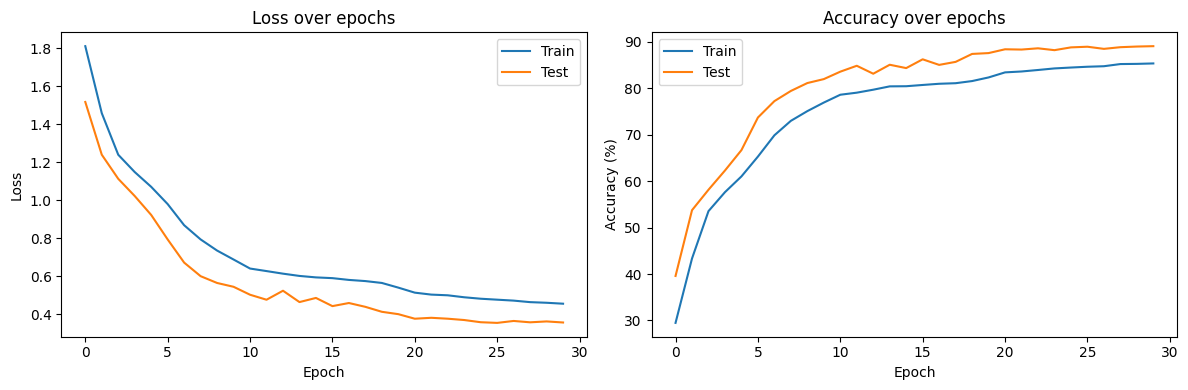

In [26]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(test_losses, label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(test_accs, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

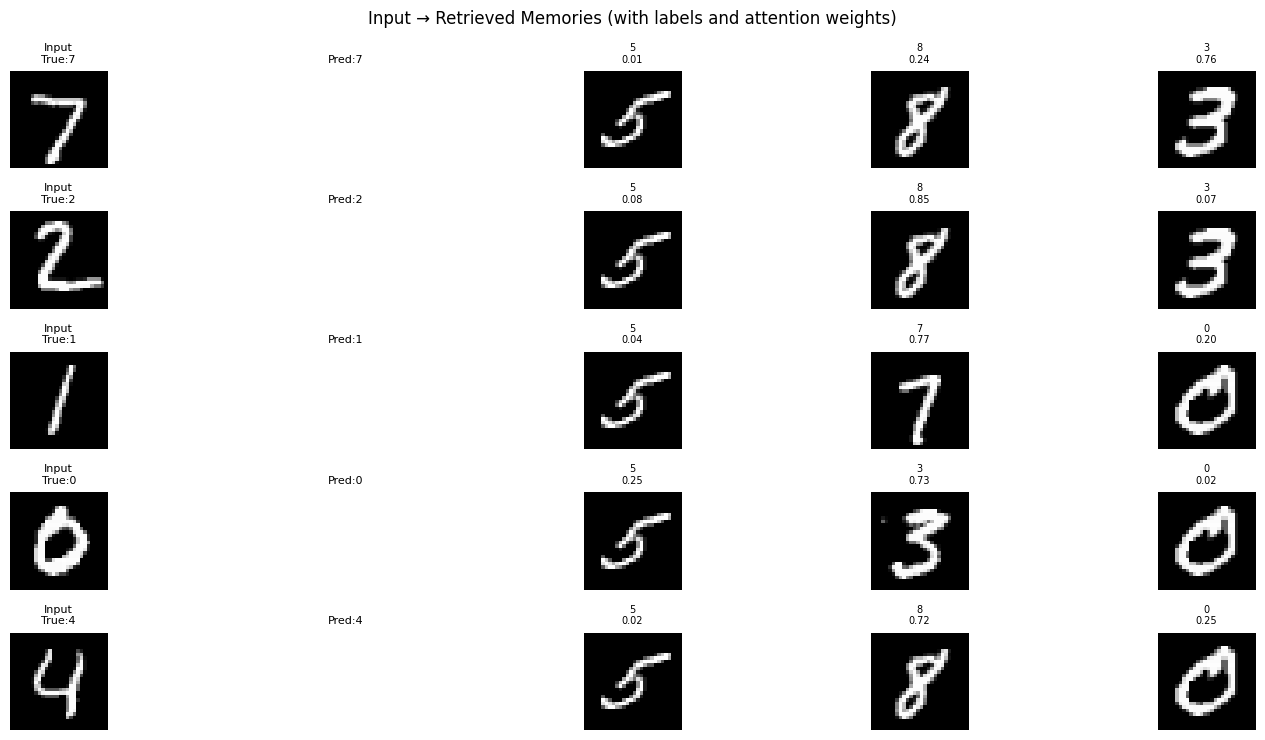

In [27]:
def visualize_memory_retrieval(model, test_loader, num_samples=5):
    """Visualize how the model retrieves memories for classification"""
    model.eval()
    
    # Get a batch
    data, target = next(iter(test_loader))
    data, target = data[:num_samples].to(device), target[:num_samples].to(device)
    
    with torch.no_grad():
        logits, info = model(data)
        pred = logits.argmax(dim=1)
    
    k = info['retrieved_images'].shape[1]  # Get actual k from model
    fig, axes = plt.subplots(num_samples, k + 2, figsize=(3 * (k + 2), num_samples * 1.5))
    
    for i in range(num_samples):
        # Input image
        axes[i, 0].imshow(data[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 0].set_title(f'Input\nTrue:{target[i].item()}', fontsize=8)
        axes[i, 0].axis('off')
        
        # Empty column for spacing
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f'Pred:{pred[i].item()}', fontsize=8)
        
        # Retrieved memories (k images)
        retrieved = info['retrieved_images'][i].cpu()  # [k, 1, 28, 28]
        mem_attention = info['memory_attention'][i].cpu().numpy()  # [k]
        
        for j in range(k):
            axes[i, j + 2].imshow(retrieved[j, 0].numpy(), cmap='gray')
            # Get the label of the retrieved memory
            mem_label = memory_bank.retrieve_labels(info['indices'][i:i+1])[0, j].item()
            axes[i, j + 2].set_title(f'{mem_label}\n{mem_attention[j]:.2f}', fontsize=7)
            axes[i, j + 2].axis('off')
    
    plt.suptitle('Input → Retrieved Memories (with labels and attention weights)', fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_memory_retrieval(model, test_loader)

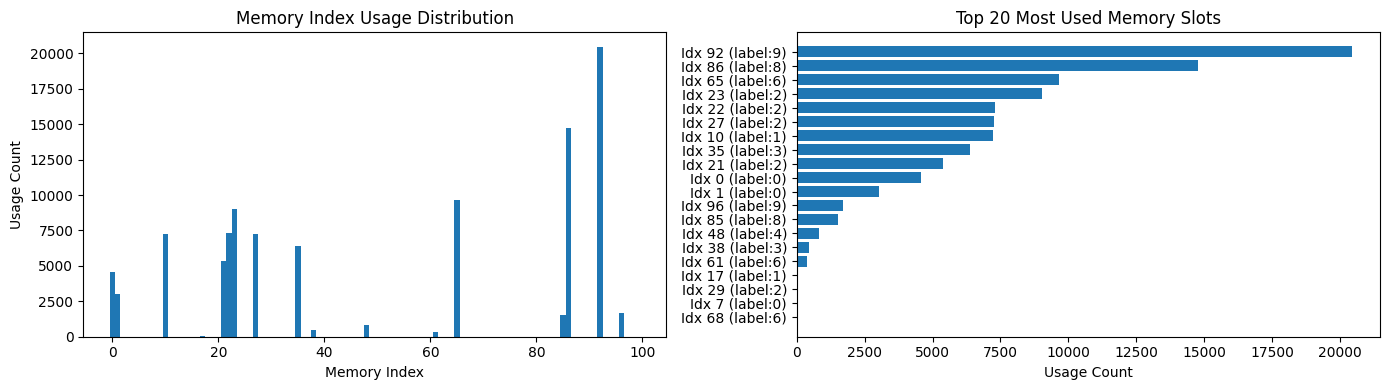


Memory coverage: 20/100 slots used
Most used slot: Index 92 (used 20458 times)


In [17]:
# Analyze which memory indices are most frequently retrieved
def analyze_memory_usage(model, test_loader):
    """Analyze how the model uses the memory bank"""
    model.eval()
    
    all_indices = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            _, info = model(data)
            all_indices.append(info['indices'].cpu())
            all_targets.append(target)
    
    all_indices = torch.cat(all_indices, dim=0)  # [N, 10]
    all_targets = torch.cat(all_targets, dim=0)  # [N]
    
    # Count index usage
    index_counts = torch.bincount(all_indices.view(-1), minlength=memory_bank.memory_size)
    
    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].bar(range(memory_bank.memory_size), index_counts.numpy(), width=1.0)
    axes[0].set_xlabel('Memory Index')
    axes[0].set_ylabel('Usage Count')
    axes[0].set_title('Memory Index Usage Distribution')
    
    # Top used indices
    top_k = min(20, memory_bank.memory_size)
    top_indices = index_counts.argsort(descending=True)[:top_k]
    top_counts = index_counts[top_indices]
    
    axes[1].barh(range(top_k), top_counts.numpy())
    axes[1].set_yticks(range(top_k))
    axes[1].set_yticklabels([f'Idx {i.item()} (label:{memory_bank.labels[i].item()})' for i in top_indices])
    axes[1].set_xlabel('Usage Count')
    axes[1].set_title(f'Top {top_k} Most Used Memory Slots')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMemory coverage: {(index_counts > 0).sum().item()}/{memory_bank.memory_size} slots used")
    print(f"Most used slot: Index {index_counts.argmax().item()} (used {index_counts.max().item()} times)")

analyze_memory_usage(model, test_loader)

In [28]:
# Final evaluation
test_loss, test_acc = evaluate(model, test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")


Final Test Accuracy: 89.05%
Final Test Loss: 0.3562
